# 🌳 Arbre de Décision sur le Dataset MNIST (Chiffres Manuscrits)

Ce notebook applique un **Arbre de Décision** pour reconnaître des chiffres de 0 à 9. 
Rappel des super-pouvoirs de cet algorithme :
1. **ZÉRO Normalisation :** Pas besoin de mettre les pixels à l'échelle (0 à 255), l'arbre s'adapte tout seul.
2. **Entraînement Actif :** Une fois l'arbre construit, il oublie le dataset et ne garde que ses règles logiques.

Nous allons analyser l'impact du paramètre `max_depth` pour contrôler le sur-apprentissage.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# --- CHARGEMENT DE TON DATASET LOCAL DANS DOCKER ---
# Modifie ces lignes selon le format exact de ton fichier dans ton conteneur
try:
    # Exemple 1 : Si ton MNIST est un fichier CSV local
    # data_mnist = pd.read_csv("chemin/vers/ton/mnist.csv")
    # X = data_mnist.drop(columns=['label']).values
    # y = data_mnist['label'].values
    
    # Exemple 2 : Si tu l'as téléchargé via Sklearn OpenML en cache local
    from sklearn.datasets import fetch_openml
    print("Tentative de chargement depuis ton cache local Sklearn...")
    mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto', data_home="./mnist_cache")
    X, y = mnist.data, mnist.target.astype(int)
    
    print("Dataset MNIST chargé avec succès depuis le stockage local !")
except Exception as e:
    print(f"Erreur de chargement. Ajuste cette cellule avec ton chemin de fichier Docker. Détail : {e}")

# Séparation : 80% entraînement, 20% test (Pas de StandardScaler requis pour l'arbre !)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

Tentative de chargement depuis ton cache local Sklearn...
Dataset MNIST chargé avec succès depuis le stockage local !


## Étape 2 : Contrôler la profondeur pour éviter le Sur-apprentissage

Si on ne limite pas l'arbre, il va créer des questions jusqu'à isoler chaque pixel de bruit.
Nous allons tester des profondeurs allant de 2 à 20 étages pour trouver la barrière idéale (`max_depth`).

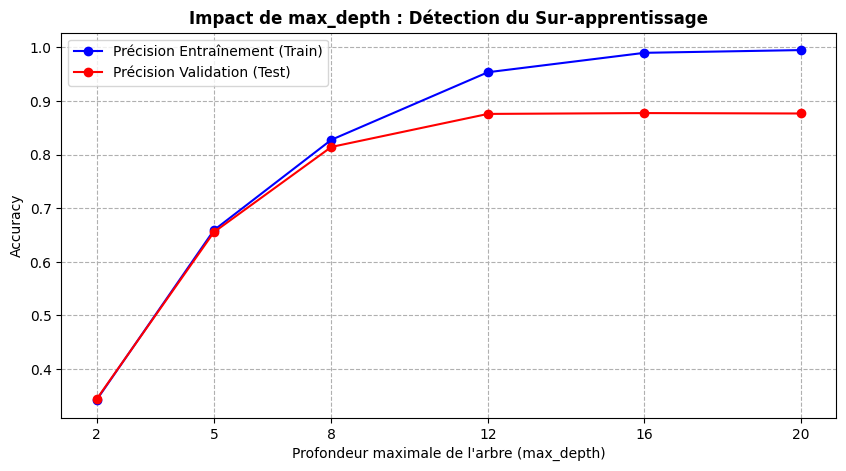

In [2]:
# Définition des profondeurs à tester
profondeurs = [2, 5, 8, 12, 16, 20]
train_scores = []
test_scores = []

for d in profondeurs:
    # Initialisation de l'arbre avec la limite de profondeur actuelle
    arbre = DecisionTreeClassifier(max_depth=d, random_state=42)
    
    # Construction des règles de décision (Entraînement global)
    arbre.fit(X_train, y_train)
    
    # Évaluation sur le Train et le Test
    train_scores.append(accuracy_score(y_train, arbre.predict(X_train)))
    test_scores.append(accuracy_score(y_test, arbre.predict(X_test)))

# ---- GRAPHIQUE DES PERFORMANCES ----
plt.figure(figsize=(10, 5))
plt.plot(profondeurs, train_scores, label="Précision Entraînement (Train)", color="blue", marker="o")
plt.plot(profondeurs, test_scores, label="Précision Validation (Test)", color="red", marker="o")

plt.title("Impact de max_depth : Détection du Sur-apprentissage", fontsize=12, fontweight='bold')
plt.xlabel("Profondeur maximale de l'arbre (max_depth)")
plt.ylabel("Accuracy")
plt.xticks(profondeurs)
plt.legend()
plt.grid(True, linestyle="--")
plt.show()

## Étape 3 : Entraînement du modèle final

Sur le graphique, tu remarqueras qu'au-delà d'une certaine profondeur, la courbe bleue (Train) continue de monter vers 100% alors que la courbe rouge (Test) stagne ou redescend. C'est la zone d'**Overfitting**.
Choisissons la profondeur qui donne le meilleur score sur la courbe rouge.

In [3]:
# Choix de la profondeur optimale d'après l'analyse visuelle (souvent autour de 12 pour MNIST)
profondeur_optimale = 12

# Création de l'arbre de décision final bridé
modele_final = DecisionTreeClassifier(max_depth=profondeur_optimale, random_state=42)

# Entraînement final (génération des règles)
modele_final.fit(X_train, y_train)

# Prédiction sur les images de test (Raisonnement instantané via l'arbre de questions)
predictions = modele_final.predict(X_test)

accuracy_finale = accuracy_score(y_test, predictions)
print(f"🎯 Précision globale de l'arbre sur MNIST (max_depth={profondeur_optimale}) : {accuracy_finale:.2%}")

🎯 Précision globale de l'arbre sur MNIST (max_depth=12) : 87.60%


## Étape 4 : Analyse des erreurs locales (Matrice de Confusion)

Puisque nous avons 10 classes (les chiffres de 0 à 9), la matrice sera un tableau $10 \times 10$. 
Elle nous permet de voir instantanément si les questions de notre arbre ont tendance à confondre des chiffres géométriquement proches, comme le **3** et le **8**, ou le **4** et le **9**.

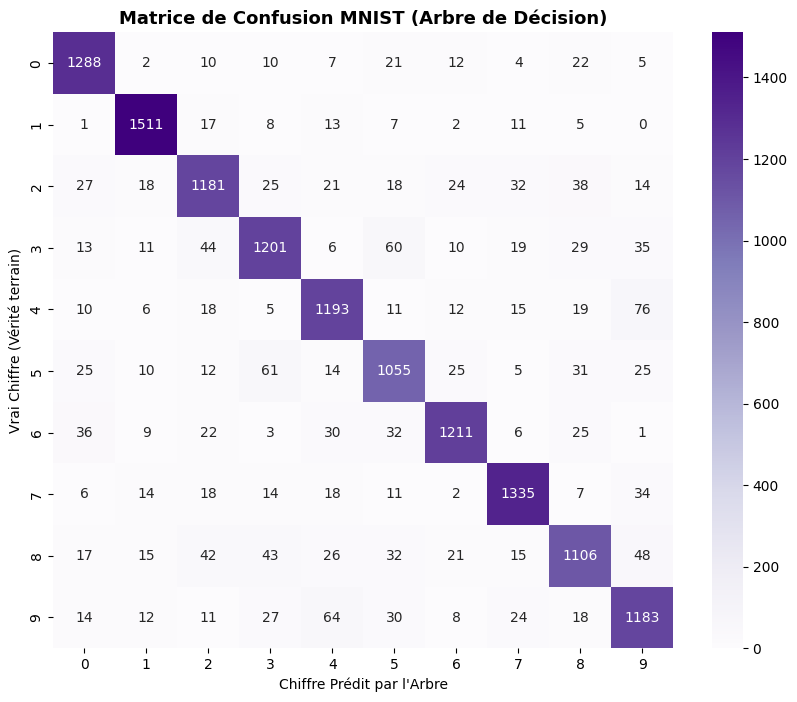


=== RAPPORT DE CLASSIFICATION POUR CHAQUE CHIFFRE ===
              precision    recall  f1-score   support

           0       0.90      0.93      0.91      1381
           1       0.94      0.96      0.95      1575
           2       0.86      0.84      0.85      1398
           3       0.86      0.84      0.85      1428
           4       0.86      0.87      0.87      1365
           5       0.83      0.84      0.83      1263
           6       0.91      0.88      0.90      1375
           7       0.91      0.92      0.91      1459
           8       0.85      0.81      0.83      1365
           9       0.83      0.85      0.84      1391

    accuracy                           0.88     14000
   macro avg       0.87      0.87      0.87     14000
weighted avg       0.88      0.88      0.88     14000



In [4]:
# Calcul de la matrice de confusion globale
matrice_conf = confusion_matrix(y_test, predictions)

# Affichage graphique avec une heatmap Seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(matrice_conf, annot=True, fmt='d', cmap='Purples',
            xticklabels=[str(i) for i in range(10)],
            yticklabels=[str(i) for i in range(10)])

plt.title(f"Matrice de Confusion MNIST (Arbre de Décision)", fontsize=13, fontweight='bold')
plt.ylabel("Vrai Chiffre (Vérité terrain)")
plt.xlabel("Chiffre Prédit par l'Arbre")
plt.show()

# Affichage des métriques détaillées par chiffre
print("\n=== RAPPORT DE CLASSIFICATION POUR CHAQUE CHIFFRE ===")
print(classification_report(y_test, predictions))

## Étape 5 : Visualisation de la structure de l'Arbre de Décision

Pour voir concrètement comment notre "détective méthodique" pose ses questions, nous pouvons dessiner sa structure géométrique. 

Chaque boîte (nœud) va te montrer :
*   La question posée (ex: `Pixel_350 <= 12.5`).
*   L'indice de **Gini** (le niveau d'impureté actuel).
*   La couleur de la boîte, qui représente la classe majoritaire à cette étape (plus la couleur est foncée, plus le nœud est pur).

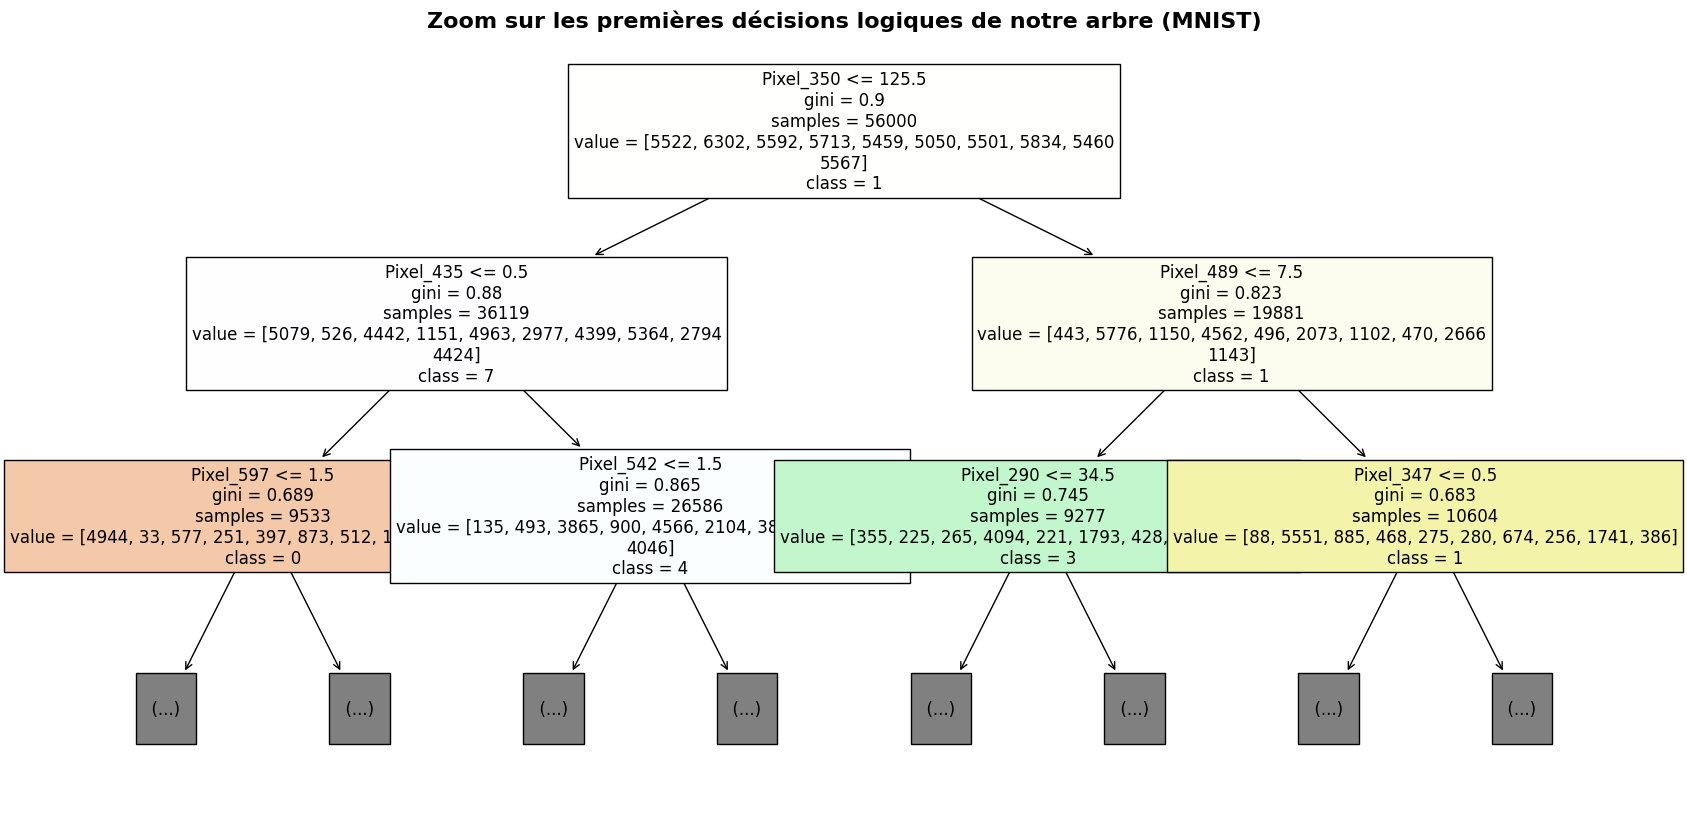

In [5]:
# Importation de l'outil de dessin d'arbre de Scikit-Learn
from sklearn.tree import plot_tree

# 1. Configuration d'une grande taille de figure pour que le texte reste lisible
plt.figure(figsize=(20, 10))

# 2. Dessin de l'arbre
# max_depth=2 permet de zoomer uniquement sur la racine et les 2 premiers niveaux de branches
# filled=True colore les boîtes selon le chiffre majoritaire détecté
plot_tree(modele_final, 
          max_depth=2, 
          filled=True, 
          feature_names=[f"Pixel_{i}" for i in range(X.shape[1])],
          class_names=[str(i) for i in range(10)],
          fontsize=12)

# 3. Personnalisation du titre et affichage final
plt.title("Zoom sur les premières décisions logiques de notre arbre (MNIST)", fontsize=16, fontweight='bold')
plt.show()